# Base CNN Training for Posture Classification (FP32)

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras
import keras_tuner

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset
from bedposip.model import (
    create_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

TUNE = False


I0000 00:00:1785196871.683412    2542 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


Dataset shapes:
  Train: (119999, 8, 8, 1), labels: (119999,)
  Val:   (60000, 8, 8, 1), labels: (60000,)
  Test:  (120001, 8, 8, 1), labels: (120001,)


### Encoding

In [4]:
class_names = {"lateral_L": 0, "lateral_R": 1, "supine": 2}

## Configuration

In [5]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='base', patience=10)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau


## Base Model

In [6]:
# Create and inspect model
base_model = create_model(num_classes=NUM_CLASSES)
base_model.summary()

check_layer_trainable_params(base_model)

I0000 00:00:1785196874.990867    2542 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5386 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,443 (40.79 KB)

 Trainable params: 10,119 (39.53 KB)

 Non-trainable params: 324 (1.27 KB)

conv_1: 144
conv_2: 2304
conv_3: 3456
dense_1: 1008
dense_2: 2688
output: 192


### Training

Epoch 1/50


I0000 00:00:1785196877.174666    2861 service.cc:153] XLA service 0x7fde88039a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785196877.174679    2861 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785196877.220059    2861 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785196877.493122    2861 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1785196877.513692    2861 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3685__.49


  59/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4602 - loss: 1.1234  

I0000 00:00:1785196882.149812    2861 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3724/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7132 - loss: 0.6587

I0000 00:00:1785196887.813989    2858 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3685__.49


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.7789 - loss: 0.5324 - val_accuracy: 0.8394 - val_loss: 0.4079 - learning_rate: 0.0010
Epoch 2/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8501 - loss: 0.3791 - val_accuracy: 0.8780 - val_loss: 0.3167 - learning_rate: 0.0010
Epoch 3/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8699 - loss: 0.3338 - val_accuracy: 0.8911 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 4/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8809 - loss: 0.3065 - val_accuracy: 0.8947 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 5/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8892 - loss: 0.2878 - val_accuracy: 0.8948 - val_loss: 0.2681 - learning_rate: 0.0010
Epoch 6/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8938 - loss: 0.2742 - val_accuracy: 0.9007 - val_loss: 0.2538 - learning_rate: 0.0010
Epoch 7/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8978 - loss: 0.264

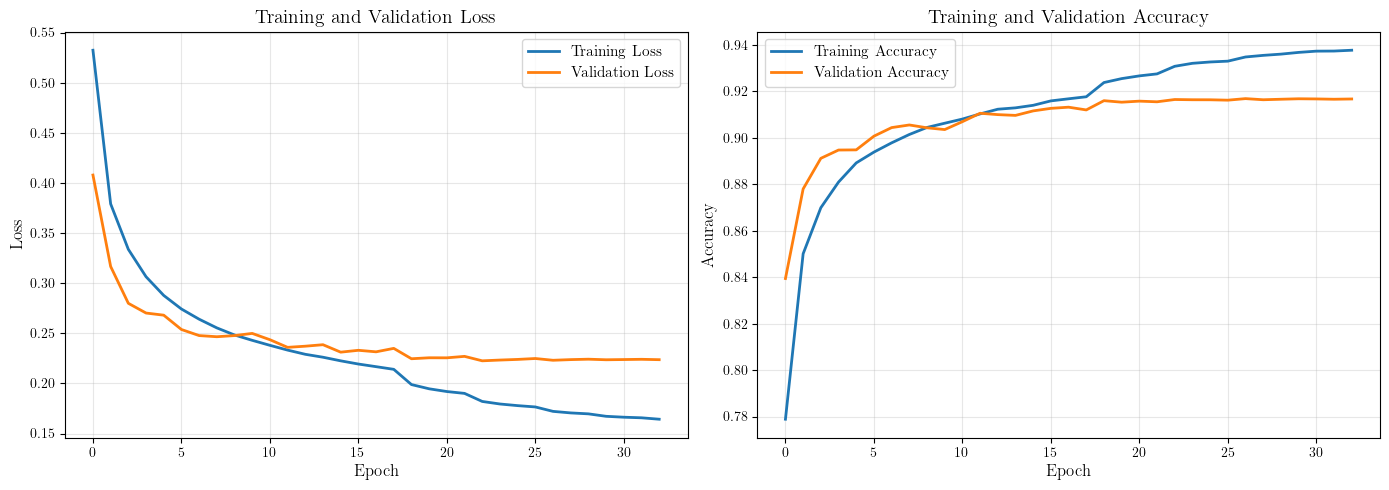

In [7]:
# Train the model
base_history = train_model(
    base_model, X_train, y_train, X_val, y_val, callbacks,
    batch_size=32, epochs=50,
)
plot_training_history(base_history, model_name='posture_classifier_base', save=True)

## Tuned Model

Hyperparameter optimization (KerasTuner)

In [8]:
tuner = keras_tuner.Hyperband(
    hypermodel=create_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    overwrite=TUNE,
    directory='output/tuning',
    project_name='posture_cnn',
    )

tuner.search_space_summary()

Reloading Tuner from output/tuning/posture_cnn/tuner0.json
Search space summary
Default search space size: 6
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 48, 'step': 4, 'sampling': 'linear'}
densefilters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 64, 'step': 4, 'sampling': 'linear'}
densefilters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 64, 'step': 4, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [9]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
tuned_model = tuner.get_best_models()[0]

tuned_model.summary()

check_layer_trainable_params(tuned_model)

Trial 60 Complete [00h 01m 24s]
val_accuracy: 0.8995833396911621

Best val_accuracy So Far: 0.918316662311554
Total elapsed time: 19h 33m 07s


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 24)       │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 24)       │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 44)       │         9,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 44)       │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 44)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 44)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 42)             │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,069 (78.39 KB)

 Trainable params: 19,701 (76.96 KB)

 Non-trainable params: 368 (1.44 KB)

conv_1: 216
conv_2: 5184
Layer conv_2 is too large (5184), are you sure you want to train?
conv_3: 9504
Layer conv_3 is too large (9504), are you sure you want to train?
dense_1: 2200
dense_2: 2100
output: 126


### Training

Epoch 1/50


I0000 00:00:1785199158.534847    2857 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5742797__.49


3739/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9270 - loss: 0.1892

I0000 00:00:1785199165.758879    2858 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5742797__.49


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9277 - loss: 0.1884 - val_accuracy: 0.9203 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 2/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9307 - loss: 0.1815 - val_accuracy: 0.9196 - val_loss: 0.2178 - learning_rate: 0.0010
Epoch 3/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9329 - loss: 0.1754 - val_accuracy: 0.9163 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 4/50
3737/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9352 - loss: 0.1702
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9356 - loss: 0.1704 - val_accuracy: 0.9172 - val_loss: 0.2309 - learning_rate: 0.0010
Epoch 5/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9437 - loss: 0.1495 - val_accuracy: 0.9220 - val_loss: 0.2229 - learning_rate: 5.0000e-04
Epoch 6/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9470 - loss: 0.

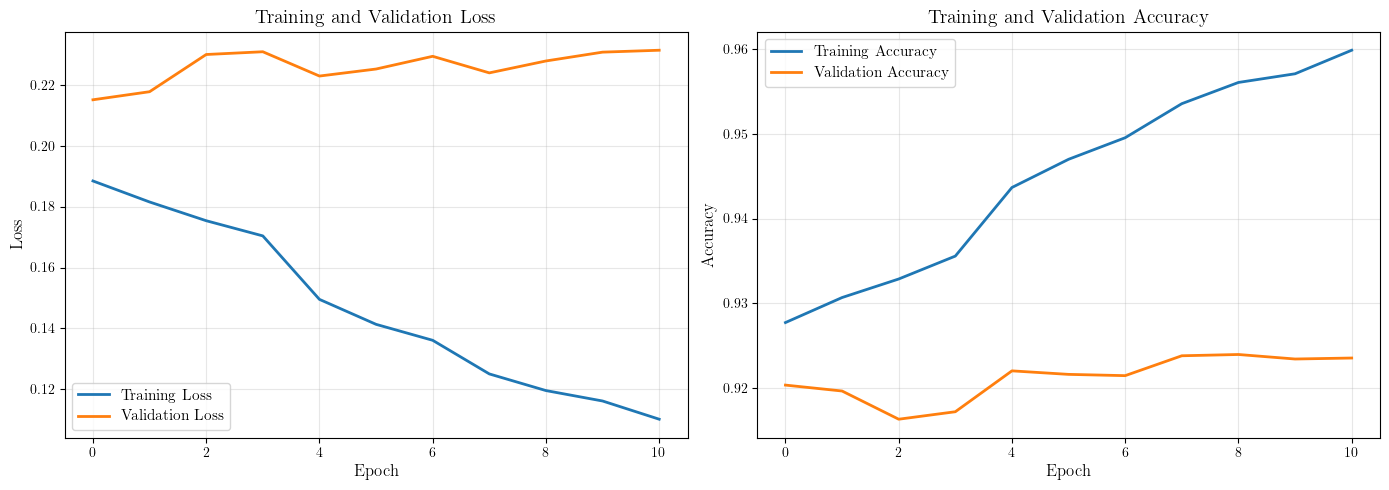

In [10]:
tuned_history = train_model(tuned_model, X_train, y_train, X_val, y_val, callbacks)
plot_training_history(tuned_history, model_name='posture_classifier_tuned', save=True)

## Model Evaluation

### Base Model


Accuracy Report for `posture_classifier_base`:
  Loss: 0.2260
  Accuracy: 91.52%

Classification Report for `posture_classifier_base`:
              precision    recall  f1-score   support

   lateral_L     0.9239    0.9049    0.9143     40000
   lateral_R     0.9047    0.9216    0.9131     40000
      supine     0.9173    0.9191    0.9182     40001

    accuracy                         0.9152    120001
   macro avg     0.9153    0.9152    0.9152    120001
weighted avg     0.9153    0.9152    0.9152    120001

Saved: figures/cm_posture_classifier_base.pdf


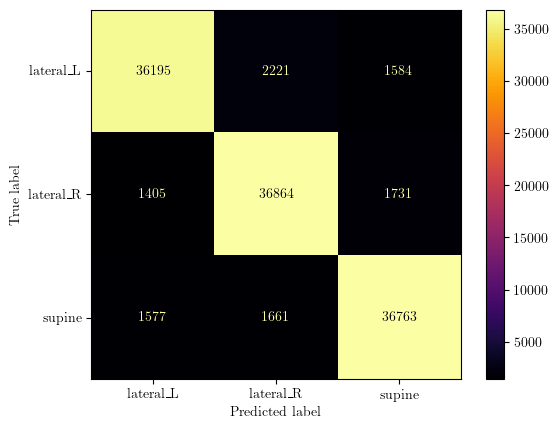

In [17]:
# Classification report for base model
_, _, _ = class_report_metric(base_model, X_test, y_test, class_names, from_logits=False, save=True)

### Tuned Model


Accuracy Report for `posture_classifier_tuned`:
  Loss: 0.2166
  Accuracy: 91.84%

Classification Report for `posture_classifier_tuned`:
              precision    recall  f1-score   support

   lateral_L     0.9214    0.9182    0.9197     40000
   lateral_R     0.9147    0.9137    0.9142     40000
      supine     0.9192    0.9235    0.9213     40001

    accuracy                         0.9184    120001
   macro avg     0.9184    0.9184    0.9184    120001
weighted avg     0.9184    0.9184    0.9184    120001

Saved: figures/cm_posture_classifier_tuned.pdf


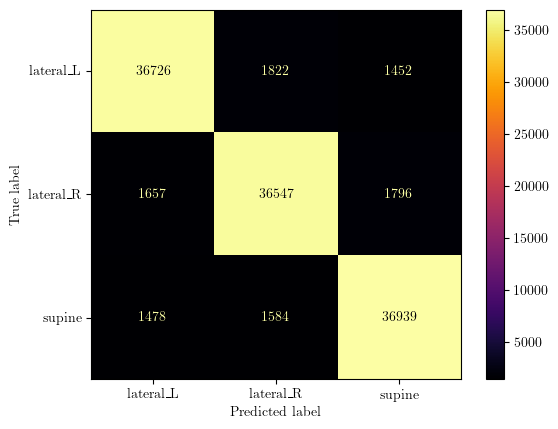

In [18]:
# Classification report for tuned model
_, _, _ = class_report_metric(tuned_model, X_test, y_test, class_names, from_logits=False, save=True)

## Model Saving

In [19]:
# Save models
save_model(base_model, output_dir='output')
save_model(tuned_model, output_dir='output')


Model saved to: output/posture_classifier_base.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 10,443

Model saved to: output/posture_classifier_tuned.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_tuned
  Total parameters: 20,069
